<a href="https://colab.research.google.com/github/yajima-yasutoshi/ADS2026/blob/main/20261006/%E5%8F%AF%E8%A6%96%E5%8C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# データ可視化によるデータ理解


#環境の準備

グラフで日本語を用いるため、日本語フォントを扱うパッケージをインストールする。

In [ ]:
%%capture
#初回のみ実行すればよい
!pip -q install japanize-matplotlib
#!pip -q install matplotlib_fontja

また、本資料では次のライブラリを用いる。

| ライブラリ | 主な用途 |
|---|---|
| NumPy | 数値計算 |
| pandas | データの読み込み、加工、集計 |
| Matplotlib | グラフの詳細設定 |
| seaborn | 統計的な可視化 |



In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
#import matplotlib_fontja
import seaborn as sns

# 表示設定
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# 再現性を確保するため乱数シードを設定する
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", context="notebook")
BASE_COLOR = sns.color_palette("colorblind")[0]
plt.rcParams['font.family'] = 'IPAexGothic'

# print(f"pandas: {pd.__version__}")
# print(f"seaborn: {sns.__version__}")

#データの読み込み

本資料では `customer_data.xlsx` を使用する。このファイルは、
GitHubから読み込むことができる


In [ ]:
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "yajima-yasutoshi/shunan-u/main/data/customer_data.xlsx"
)
raw_df = pd.read_excel(DATA_URL)
print(f"読み込み時点の形状: {raw_df.shape}")
raw_df.head()

読み込み時点の形状: (500, 9)


,顧客ID,性別,年齢,職業,年収,スマホの所有,スマホ利用時間,Aの利用回数,Bの利用回数
0,81336944,男性,NaN,会社員,393,はい,1.67,1.00,12
1,41990933,女性,51.00,NaN,450,はい,2.44,0.00,11
2,84494791,男性,45.00,会社員,497,はい,0.69,1.00,21
3,29406622,女性,27.00,公務員,313,はい,1.40,NaN,8
4,20205360,女性,61.00,会社員,292,はい,1.77,2.00,24


#可視化前のデータ理解と品質確認
可視化の前に最低限の構造確認を行う必要がある。
主に確認すべき観点は次のとおりである。

- 行数と列数
- 各列の名称とデータ型
- 欠損値
- 重複行
- カテゴリ表記の揺れ
- 値の範囲
- 外れ値


In [ ]:
print("形状:", raw_df.shape)
print("\n列名:")
print(raw_df.columns.tolist())

print("\nデータ型:")
raw_df.info()

形状: (500, 9)

列名:
['顧客ID', '性別', '年齢', '職業', '年収', 'スマホの所有', 'スマホ利用時間', 'Aの利用回数', 'Bの利用回数']

データ型:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   顧客ID     500 non-null    int64  
 1   性別       497 non-null    object 
 2   年齢       496 non-null    float64
 3   職業       499 non-null    object 
 4   年収       500 non-null    int64  
 5   スマホの所有   500 non-null    object 
 6   スマホ利用時間  500 non-null    float64
 7   Aの利用回数   499 non-null    float64
 8   Bの利用回数   500 non-null    int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 35.3+ KB


In [ ]:
# 先頭5行と末尾5行を確認する
display(raw_df.head())
display(raw_df.tail())

,顧客ID,性別,年齢,職業,年収,スマホの所有,スマホ利用時間,Aの利用回数,Bの利用回数
0,81336944,男性,NaN,会社員,393,はい,1.67,1.00,12
1,41990933,女性,51.00,NaN,450,はい,2.44,0.00,11
2,84494791,男性,45.00,会社員,497,はい,0.69,1.00,21
3,29406622,女性,27.00,公務員,313,はい,1.40,NaN,8
4,20205360,女性,61.00,会社員,292,はい,1.77,2.00,24


,顧客ID,性別,年齢,職業,年収,スマホの所有,スマホ利用時間,Aの利用回数,Bの利用回数
495,45099496,男性,45.00,公務員,411,はい,2.94,6.00,19
496,30507179,男性,18.00,学生,215,はい,2.01,12.00,8
497,30507179,男性,18.00,学生,215,はい,2.01,12.00,8
498,59997136,男性,65.00,公務員,556,いいえ,0.00,2.00,12
499,99854703,NaN,26.00,会社員,290,はい,1.28,9.00,18


In [ ]:
# 欠損値と欠損率を確認する
missing_summary = pd.DataFrame({
    "欠損数": raw_df.isna().sum(),
    "欠損率(%)": raw_df.isna().mean().mul(100),
}).sort_values("欠損数", ascending=False)

missing_summary.T

,年齢,性別,職業,Aの利用回数,顧客ID,年収,スマホの所有,スマホ利用時間,Bの利用回数
欠損数,4.00,3.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
欠損率(%),0.80,0.60,0.20,0.20,0.00,0.00,0.00,0.00,0.00


##データ型と値の妥当性を整える

ここから先の可視化を安定して行うため、元データ `raw_df` は保持したまま、分析用データ `df` を作成する。

処理内容は次のとおりである。

1. 列名と文字列の前後空白を除去する。
2. 数値列を数値型へ変換する。
3. 完全重複行を除去する。
4. 業務上明らかに不正な値を欠損値として扱う。

実務では、欠損行の除外が適切とは限らない。補完、別カテゴリ化、追加確認などを含め、分析目的と欠損原因に応じて判断する必要がある。


In [ ]:
df = raw_df.copy()

# 列名から前後のスペースを削除
df.columns = df.columns.astype(str).str.strip()

# 文字列列の前後空白を除去する
text_columns = df.select_dtypes(include=["object", "string"]).columns
for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

# 数値列を数値型へ変換する
numeric_columns = [
    "年齢",
    "年収",
    "スマホ利用時間",
    "Aの利用回数",
    "Bの利用回数",
]
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 重複行を除去する
df = df.drop_duplicates().copy()

# 業務上明らかに不正な値を欠損値へ置換する
if "年齢" in df.columns:
    df.loc[~df["年齢"].between(0, 120), "年齢"] = np.nan

for col in ["年収", "スマホ利用時間", "Aの利用回数", "Bの利用回数"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

required_columns = [
    "性別",
    "年齢",
    "職業",
    "年収",
    "スマホ利用時間",
    "Aの利用回数",
    "Bの利用回数",
]

# 本講義の分析に必要な列が欠損している行を除外する
df = df.dropna(subset=required_columns).copy()

print(f"加工前: {raw_df.shape}")
print(f"加工後: {df.shape}")
df.head()

加工前: (500, 9)
加工後: (487, 9)


,顧客ID,性別,年齢,職業,年収,スマホの所有,スマホ利用時間,Aの利用回数,Bの利用回数
2,84494791,男性,45.00,会社員,497.00,はい,0.69,1.00,21.00
4,20205360,女性,61.00,会社員,292.00,はい,1.77,2.00,24.00
5,55928989,男性,39.00,公務員,317.00,はい,1.60,1.00,11.00
6,46119309,女性,12.00,学生,0.00,いいえ,0.00,4.00,8.00
7,81075284,男性,12.00,学生,0.00,いいえ,0.00,11.00,13.00


##外れ値候補をフラグ化する

例えば、
四分位範囲（IQR）を用い次の範囲外を外れ値候補とする。

$$
	\text{下限} = Q_1-1.5	\times IQR
$$

$$
	\text{上限} = Q_3+1.5	\times IQR
$$

> これは目安の一つであり外れ値を断定する絶対的な基準ではない。
外れ値の処理には、業務ルール、測定方法なども確認する必要がある。


In [ ]:
def iqr_outlier_flag(series, k=1.5):
    # IQR基準による外れ値候補フラグと上下限を返す。
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    flag = ~series.between(lower, upper)
    return flag, lower, upper

income_flag, income_lower, income_upper = iqr_outlier_flag(df["年収"])
df["年収_IQR外"] = income_flag

print(f"年収のIQR下限: {income_lower:,.1f}")
print(f"年収のIQR上限: {income_upper:,.1f}")
print(f"外れ値候補数: {df['年収_IQR外'].sum()}")

df.loc[df["年収_IQR外"], ["性別", "年齢", "職業", "年収"]]

年収のIQR下限: -300.8
年収のIQR上限: 1,149.2
外れ値候補数: 3


,性別,年齢,職業,年収
37,男性,64.00,その他,"1,304.00"
174,男性,65.00,その他,"1,238.00"
336,男性,63.00,その他,"1,263.00"


#可視化を設計する原則

グラフは**分析上の問い**から選ぶ必要がある。

| 分析上の問い | 主なグラフ | 主に確認すること |
|---|---|---|
| カテゴリごとのレコード（件）数を知りたい | countplot | 頻度、希少カテゴリ、偏り |
| カテゴリごとの平均や合計を比較したい | barplot、pointplot | 水準差、不確実性 |
| 1つの数値変数の分布を知りたい | histplot、ECDF、boxplot | 中心、ばらつき、歪み、裾、外れ値候補 |
| カテゴリごとに数値分布を比較したい | boxplot、violinplot、stripplot | 中央値、ばらつき、分布形状、個票 |
| 2つの数値変数の関係を知りたい | scatterplot、regplot、2次元ヒストグラム | 傾向、非線形性、群差、外れ値、点の重なり |
| 2つのカテゴリ変数の関係を知りたい | クロス集計、構成比棒グラフ、heatmap | 構成比の違い |
| 多数の数値変数を俯瞰したい | 相関ヒートマップ、pairplot | 関係の候補、冗長な変数 |



#カテゴリ型変数の可視化

##レコード（件）数の確認

カテゴリごとのレコード（件）数は、
`value_counts()`で数値として確認できる。

カテゴリ変数では、値の種類数である**基数（cardinality）**
に注目する。
基数が非常に大きい場合は、通常の棒グラフでは読みにくい。反対に、極端に件数の少ない希少カテゴリは、統合を検討する必要がある。

In [ ]:
occupation_counts = df["職業"].value_counts()
occupation_counts

,count
職業,
その他,151
会社員,136
公務員,131
学生,69


##countplot

`countplot`は、カテゴリごとのレコード（行）数を棒の高さで示す。
`y=` で集計項目を指定することで横向きの棒グラフとなる。

In [ ]:
#どのようなカテゴリ値があるか確認する
df["職業"].unique()

<StringArray>
['会社員', '公務員', '学生', 'その他']
Length: 4, dtype: string

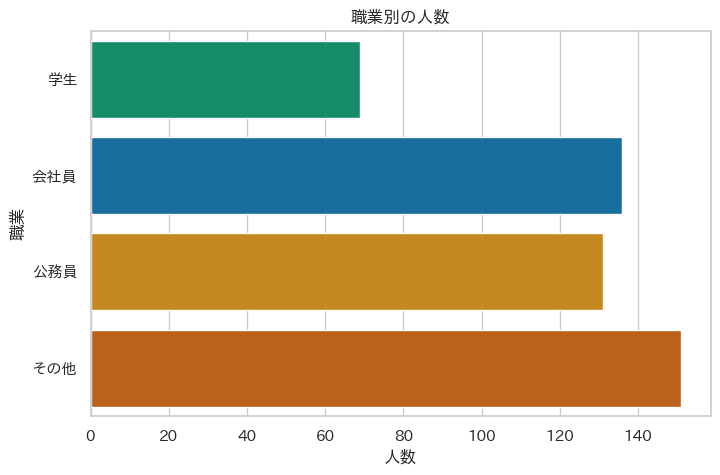

In [ ]:
occupation_order = ["学生", "会社員", "公務員", "その他"]
ax = sns.countplot(
    data=df,
    y="職業",
    order=occupation_order,
    hue="職業",
    palette="colorblind",
    legend=False,
)
ax.set(
    title="職業別の人数",
    xlabel="人数",
    ylabel="職業",
)
plt.show()

###パレットを使って色を指定する。

Seabornには多くの組み込みパレットがある。 `sns.color_palette` で指定する。


例：
`'pastel'`, `'bright'`, `'dark'`, `'colorblind'` など。

- `'colorblind'` パレットは、色覚多様な人々にも区別しやすいように設計されている。
- `'rocket'` パレットは、連続的な数値データを表現するのに適しており、濃い色から明るい色へ変化する。


In [ ]:
# 'colorblind' パレットの例
display(sns.color_palette('pastel'))

# 'rocket' パレットの例 (10色)
display(sns.color_palette('rocket', n_colors=10))

# 'vlag' パレットの例 (7色）
display(sns.color_palette('vlag', n_colors=7))

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019),
 (0.8156862745098039, 0.7333333333333333, 1.0),
 (0.8705882352941177, 0.7333333333333333, 0.6078431372549019),
 (0.9803921568627451, 0.6901960784313725, 0.8941176470588236),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529),
 (1.0, 0.996078431372549, 0.6392156862745098),
 (0.7254901960784313, 0.9490196078431372, 0.9411764705882353)]

[(0.13501631, 0.07585609, 0.19044109),
 (0.26930915, 0.1091727, 0.2772502),
 (0.41282936, 0.12164769, 0.33467689),
 (0.57077365, 0.11135597, 0.35827146),
 (0.72398193, 0.08688725, 0.33943958),
 (0.85281737, 0.15657772, 0.27909826),
 (0.93078135, 0.31373977, 0.24468803),
 (0.95626788, 0.49187351, 0.33985601),
 (0.96388426, 0.64484214, 0.4861196),
 (0.96810471, 0.78634563, 0.66773889)]

[(0.40384046, 0.54623277, 0.74549872),
 (0.60934065, 0.68212194, 0.79422987),
 (0.8107221, 0.83132983, 0.87695392),
 (0.9805997, 0.96155216, 0.95813083),
 (0.90771071, 0.78502727, 0.77728196),
 (0.82740268, 0.59209095, 0.58167944),
 (0.74854331, 0.40485474, 0.3979589)]

##hueによる層別

`hue`には、さらに分類したいカテゴリ型変数を指定する。色の凡例だけに依存しないよう、タイトル、軸ラベル、凡例名を明示する。

In [ ]:
display(df["性別"].unique())

<StringArray>
['男性', '女性']
Length: 2, dtype: string

In [ ]:
#colorblind で利用可能な色を確認する
color = sns.color_palette("colorblind", n_colors=10)
display(color)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [ ]:
gender_order = ["女性", "男性"]
#gender_palette = {"女性": color[4], "男性": color[0]}
gender_palette = {gender_order[0]: color[4], gender_order[1]: color[0]}

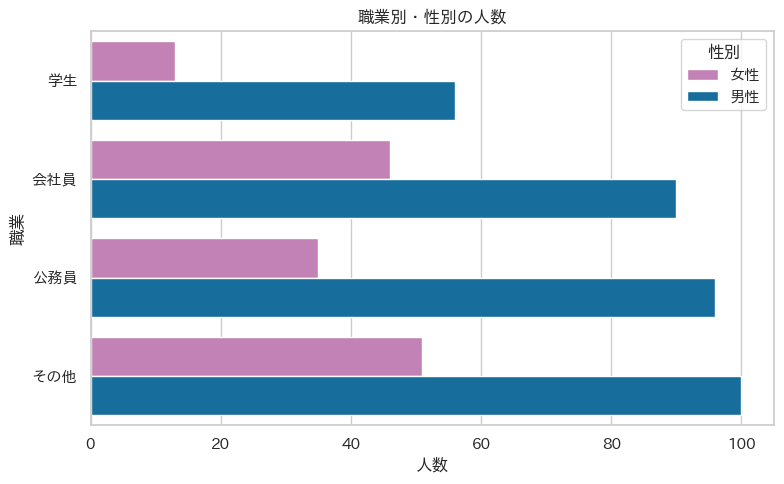

In [ ]:
ax = sns.countplot(
    data=df,
    y="職業",
    order=occupation_order,
    hue="性別",
    hue_order=gender_order,
    palette=gender_palette,
)
ax.set(
    title="職業別・性別の人数",
    xlabel="人数",
    ylabel="職業",
)
ax.legend(title="性別")
plt.tight_layout()
plt.show()

#集計値の可視化

##barplotの基本

`barplot`は、カテゴリごとに数値変数を集計して表示する。
既定の集計量は平均、
また、ブートストラップによる95%信頼区間がエラーバーとして表示される。

>ブートストラップ法による信頼区間の計算方法について調べ、実装してみよ。


In [ ]:
gender_order

['女性', '男性']

In [ ]:
summary_a_by_gender = (
    df.groupby("性別")["Aの利用回数"]
      .agg(["count", "mean", "median", "std"])
      .reindex(gender_order) #列の並びを指定
)
summary_a_by_gender

,count,mean,median,std
性別,,,,
女性,145,3.03,3.00,1.76
男性,342,5.66,4.00,4.18


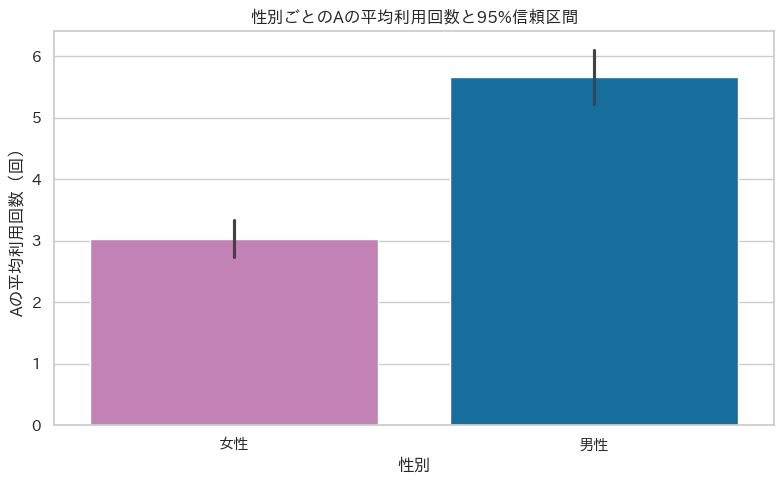

In [ ]:
ax = sns.barplot(
    data=df,
    x="性別",
    y="Aの利用回数",
    order=gender_order,
    estimator="mean",
    errorbar=("ci", 95),
    seed=RANDOM_SEED,
    palette=gender_palette,
    hue="性別",
    legend=False,
)
ax.set(
    title="性別ごとのAの平均利用回数と95%信頼区間",
    xlabel="性別",
    ylabel="Aの平均利用回数（回）",
)
plt.tight_layout()
plt.show()

##代表的なオプション

| 指定 | 意味 |
|---|---|
| `estimator="mean"` | 平均 |
| `estimator="median"` | 中央値 |
| `estimator="sum"` | 合計 |
| `errorbar=("ci", 95)` | 95%信頼区間 |
| `errorbar=("sd",1)` | 平均±1標準偏差 |
| `errorbar=("se",1)` | 平均±1標準誤差 |
| `errorbar=None` | エラーバーを表示しない |


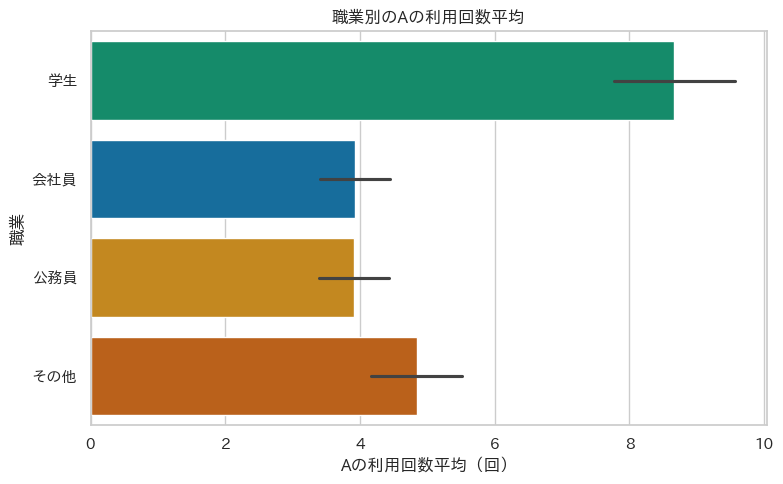

In [ ]:
ax = sns.barplot(
    data=df,
    y="職業",
    x="Aの利用回数",
    order=occupation_order,
    estimator="mean",
    errorbar=("se",2),
    hue="職業",
    palette="colorblind",
    legend=False,
)
ax.set(
    title="職業別のAの利用回数平均",
    xlabel="Aの利用回数平均（回）",
    ylabel="職業",
)
plt.tight_layout()
plt.show()

##平均だけでなく元データも示す

平均値だけでは、分布の偏り、ばらつき、外れ値、サンプル数が見えにくい。`pointplot`や`stripplot`を組み合わせると、推定値と個々の観測値を同時に確認できる。

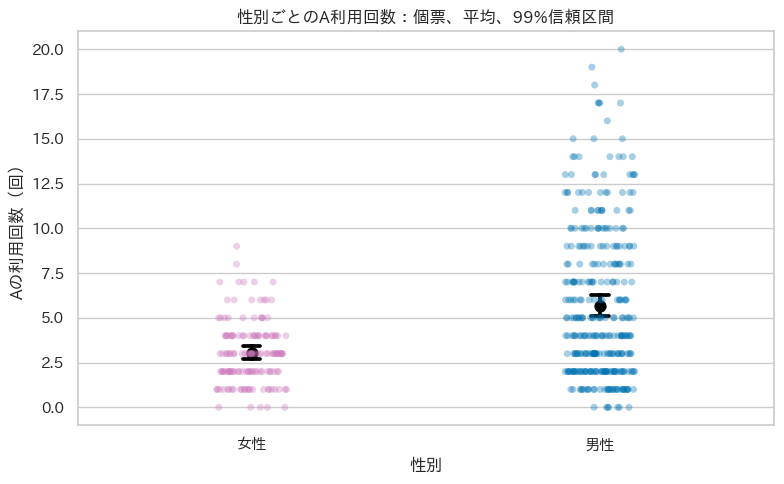

In [ ]:
ax = sns.stripplot(
    data=df,
    x="性別",
    y="Aの利用回数",
    order=gender_order,
    hue="性別",
    palette=gender_palette,
    alpha=0.35,
#    jitter=0.25,
    legend=False,
)
sns.pointplot(
    data=df,
    x="性別",
    y="Aの利用回数",
    order=gender_order,
    estimator="mean",
    errorbar=("ci", 99),
    seed=RANDOM_SEED,
    color='black',
    capsize=0.05,  # エラーバーのキャップサイズ
    linestyles="none",
    ax=ax,
)
ax.set(
    title="性別ごとのA利用回数：個票、平均、99%信頼区間",
    xlabel="性別",
    ylabel="Aの利用回数（回）",
)
plt.tight_layout()
plt.show()

#数値分布の可視化

数値変数を理解する際には、
ばらつき、歪み、裾、外れ値などを確認する。
ヒストグラム、ECDF、箱ひげ図などを組み合わせる。



##ヒストグラム

ヒストグラムは、数値を階級に分け、各階級の件数または密度を示す。棒の幅や形は`bins`や`binwidth`で調整する。


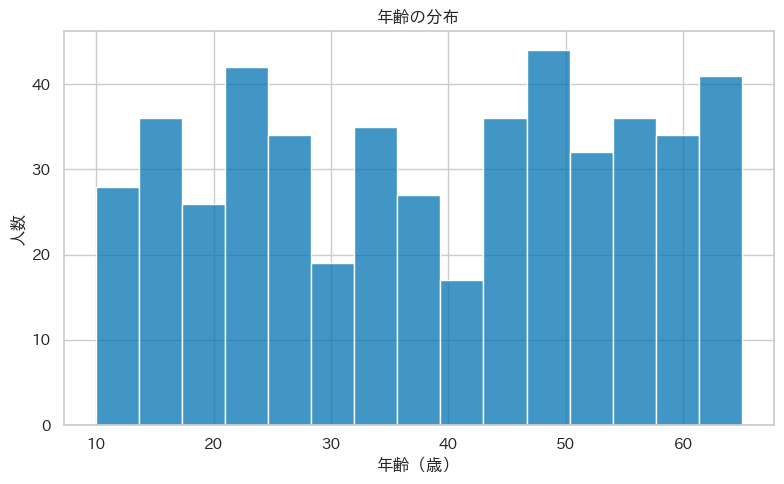

In [ ]:
ax = sns.histplot(
    data=df,
    x="年齢",
    bins=15,
    color=sns.color_palette("colorblind")[0],
)
ax.set(
    title="年齢の分布",
    xlabel="年齢（歳）",
    ylabel="人数",
)
plt.tight_layout()
plt.show()

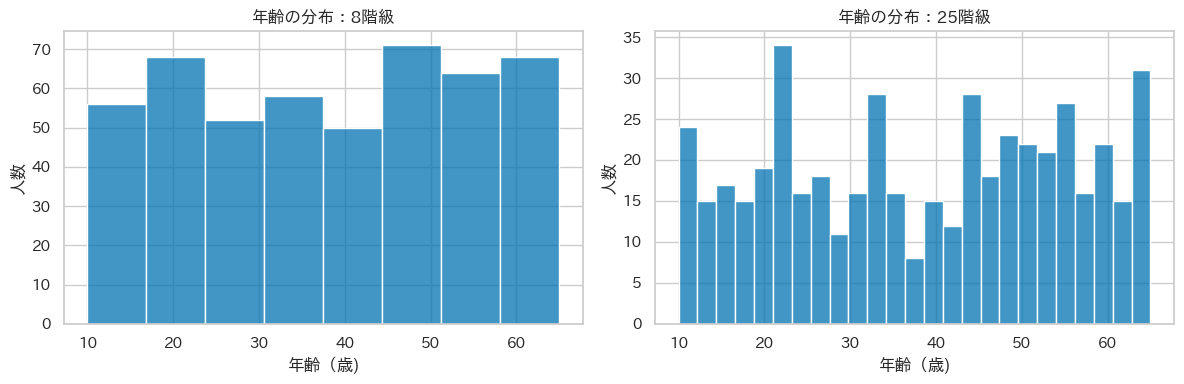

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="年齢", bins=8, color=sns.color_palette("colorblind")[0], ax=axes[0])
axes[0].set_title("年齢の分布：8階級")
axes[0].set_xlabel("年齢（歳)")
axes[0].set_ylabel("人数")

sns.histplot(data=df, x="年齢", bins=25, color=sns.color_palette("colorblind")[0], ax=axes[1])
axes[1].set_title("年齢の分布：25階級")
axes[1].set_xlabel("年齢（歳)")
axes[1].set_ylabel("人数")

plt.tight_layout()
plt.show()

##層別ヒストグラム

複数群の分布を重ねる場合、件数の違いによって見え方が変わる。比較目的に応じて、`stat="density"`や`common_norm=False`を使用する。

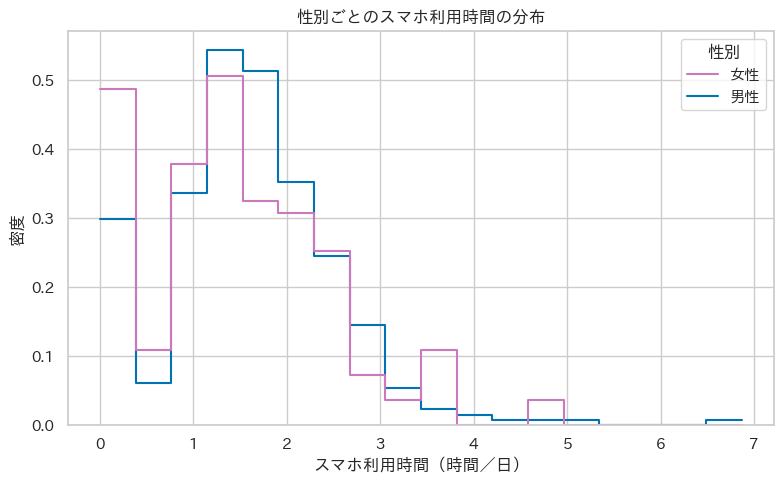

In [ ]:
ax = sns.histplot(
    data=df,
    x="スマホ利用時間",
    hue="性別",
    hue_order=gender_order,
    palette=gender_palette,
    bins=18,
    stat="density", #密度が縦軸となる
    common_norm=False, #群ごとに正規化される
    element="step",
    fill=False,
)
ax.set(
    title="性別ごとのスマホ利用時間の分布",
    xlabel="スマホ利用時間（時間／日）",
    ylabel="密度",
)
plt.tight_layout()
plt.show()

##累積分布（ECDF）

ECDFは、ある値以下のデータが全体の何割を占めるかを示す。階級幅に依存せず、中央値や上位割合を比較しやすい。

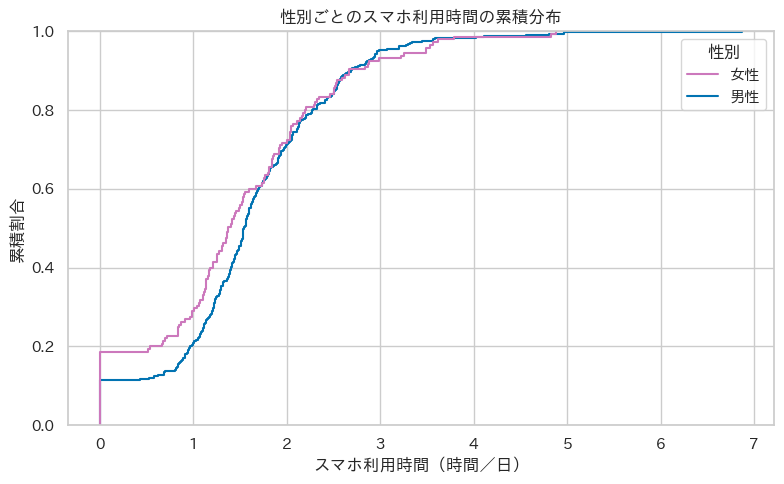

In [ ]:
ax = sns.ecdfplot(
    data=df,
    x="スマホ利用時間",
    hue="性別",
    hue_order=gender_order,
    palette=gender_palette,
)
ax.set(
    title="性別ごとのスマホ利用時間の累積分布",
    xlabel="スマホ利用時間（時間／日）",
    ylabel="累積割合",
)
plt.tight_layout()
plt.show()

##カーネル密度推定（KDE）

KDEは分布を滑らかな曲線で表す。曲線の形は帯域幅に依存し、実際には存在しない範囲へ曲線が伸びることもある。件数が少ない群や離散値には慎重に用いる必要がある。

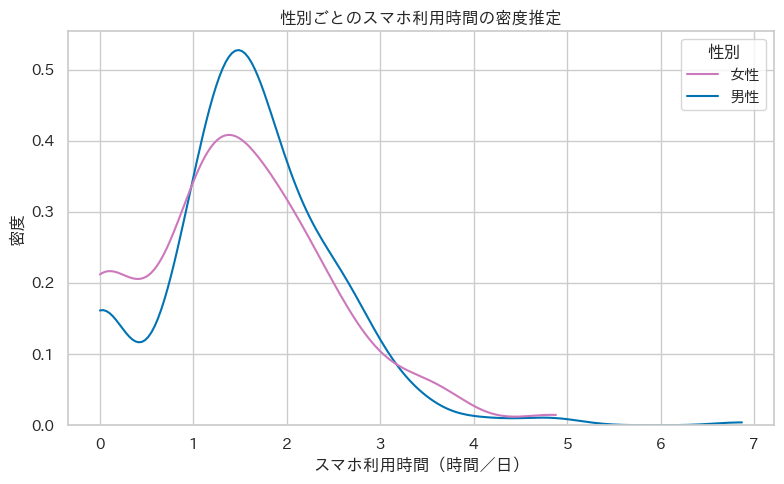

In [ ]:
ax = sns.kdeplot(
    data=df,
    x="スマホ利用時間",
    hue="性別",
    hue_order=gender_order,
    palette=gender_palette,
    common_norm=False,
    fill=False,
    cut=0,
)
ax.set(
    title="性別ごとのスマホ利用時間の密度推定",
    xlabel="スマホ利用時間（時間／日）",
    ylabel="密度",
)
plt.tight_layout()
plt.show()

##箱ひげ図

箱ひげ図は、中央値、四分位数、四分位範囲、ひげ、外れ値候補を要約して示す。

重要な点は、**ひげの端が必ずしも最大値・最小値ではない**ことである。seabornの既定設定では、ひげは第1四分位数または第3四分位数から1.5×IQR以内にある最も外側の観測値まで伸びる。範囲外の観測値は点として表示される。

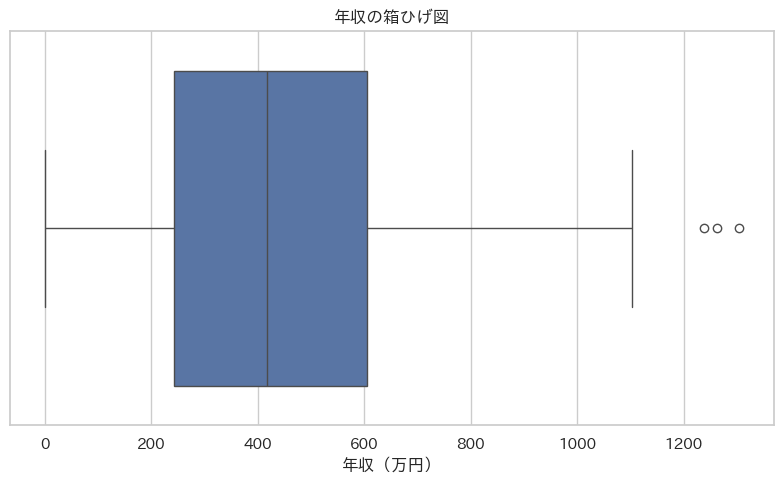

In [ ]:
ax = sns.boxplot(
    data=df,
    x="年収",
)
ax.set(
    title="年収の箱ひげ図",
    xlabel="年収（万円）",
)
plt.tight_layout()
plt.show()

In [ ]:
income_quantiles = df["年収"].quantile([0, 0.25, 0.5, 0.75, 1.0])
income_quantiles.index = ["最小値", "第1四分位数", "中央値", "第3四分位数", "最大値"]
income_quantiles.to_frame("年収（万円）")

,年収（万円）
最小値,0.00
第1四分位数,243.00
中央値,418.00
第3四分位数,605.50
最大値,"1,304.00"


##離散カウントデータの分布

`Aの利用回数`や`Bの利用回数`は、0回、1回、2回のような**離散値**である。連続量と同じ感覚で滑らかなKDEだけを描くと、実際には存在しない中間値まであるように見えるため注意が必要である。

離散カウントでは、整数値ごとの頻度が分かるヒストグラムやcountplotが適している。


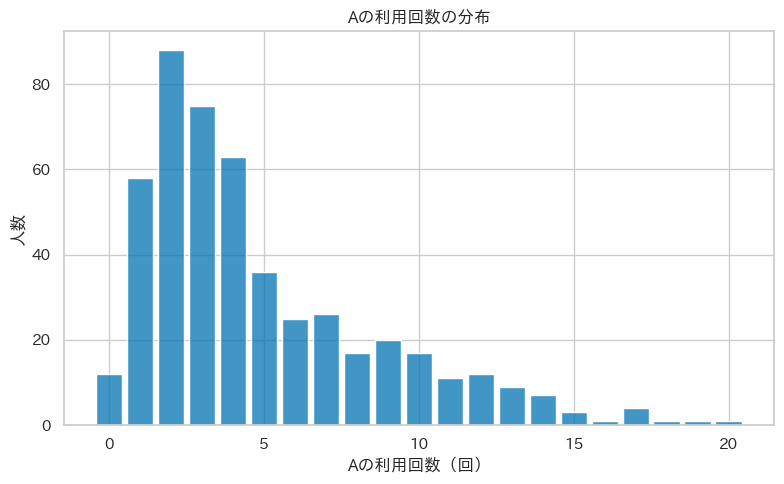

In [ ]:
ax = sns.histplot(
    data=df,
    x="Aの利用回数",
    discrete=True,
    shrink=0.85,
    color=BASE_COLOR,
)
ax.set(
    title="Aの利用回数の分布",
    xlabel="Aの利用回数（回）",
    ylabel="人数",
)
plt.tight_layout()
plt.show()


##歪んだ分布と対数尺度

売上、所得、利用金額などの正の量は、右に長い裾を持つ場合がある。極端に大きい値が存在すると、通常尺度では多くの観測値が左側へ押しつぶされて見えることがある。

その場合、**対数尺度または対数変換**によって分布構造を確認しやすくなる。ただし、変換後の図だけを示すと元の単位感が失われるため、通常尺度と併記することが望ましい。

対数変換は外れ値を「消す」処理ではない。見え方を変えて構造を確認するための手段である。


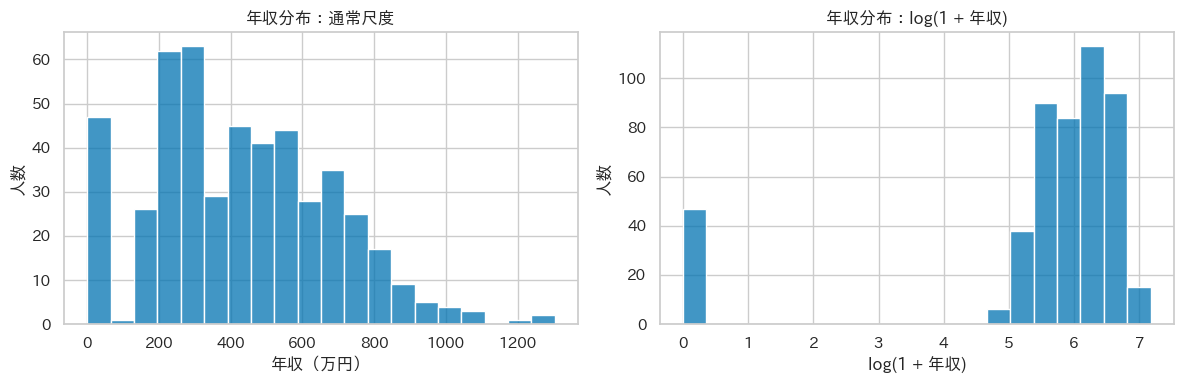

In [ ]:
positive_income = df.loc[df["年収"] >= 0, "年収"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(positive_income, bins=20, color=BASE_COLOR, ax=axes[0])
axes[0].set(
    title="年収分布：通常尺度",
    xlabel="年収（万円）",
    ylabel="人数",
)

sns.histplot(np.log1p(positive_income), bins=20, color=BASE_COLOR, ax=axes[1])
axes[1].set(
    title="年収分布：log(1 + 年収)",
    xlabel="log(1 + 年収)",
    ylabel="人数",
)

plt.tight_layout()
plt.show()


#カテゴリ変数と数値変数の関係

カテゴリ間で数値分布を比較する場合、箱ひげ図、バイオリンプロット、ストリッププロット、スウォームプロットを使い分ける。

- 箱ひげ図は要約に適する。
- バイオリンプロットは分布形状を示すが、平滑化の影響を受ける。
- ストリッププロットは個々の観測値を示す。
- スウォームプロットは点の重なりを避けるが、件数が多いと遅くなる。

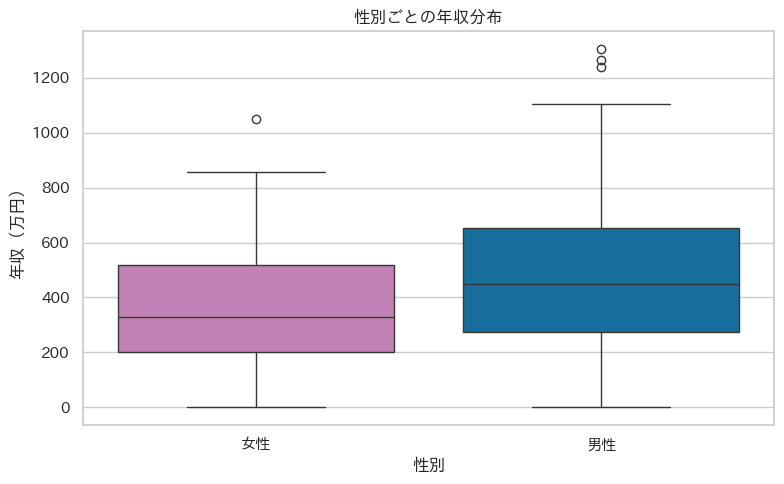

In [ ]:
ax = sns.boxplot(
    data=df,
    x="性別",
    y="年収",
    order=gender_order,
    hue="性別",
    palette=gender_palette,
    legend=False,
)
ax.set(
    title="性別ごとの年収分布",
    xlabel="性別",
    ylabel="年収（万円）",
)
plt.tight_layout()
plt.show()

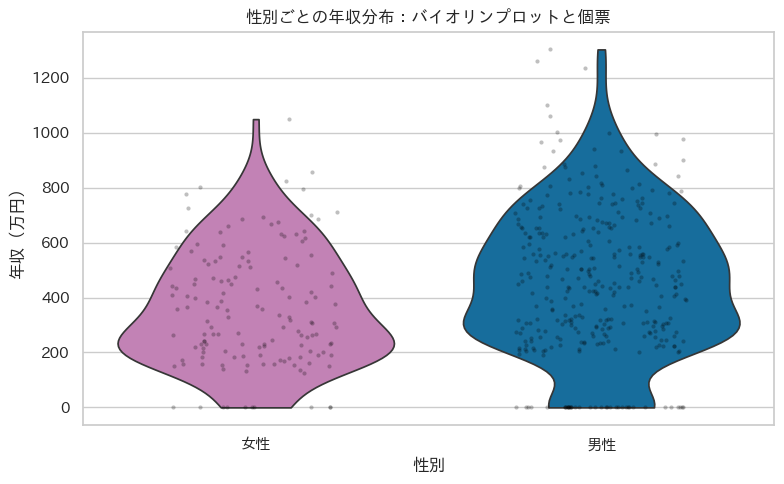

In [ ]:
ax = sns.violinplot(
    data=df,
    x="性別",
    y="年収",
    order=gender_order,
    hue="性別",
    palette=gender_palette,
    inner=None,
    cut=0,
    legend=False,
)
sns.stripplot(
    data=df,
    x="性別",
    y="年収",
    order=gender_order,
    color="black",
    alpha=0.25,
    jitter=0.25,
    size=3,
    ax=ax,
)
ax.set(
    title="性別ごとの年収分布：バイオリンプロットと個票",
    xlabel="性別",
    ylabel="年収（万円）",
)
plt.tight_layout()
plt.show()

## 職業ごとの比較

カテゴリ数が多い場合は、横向きにすると読みやすい。

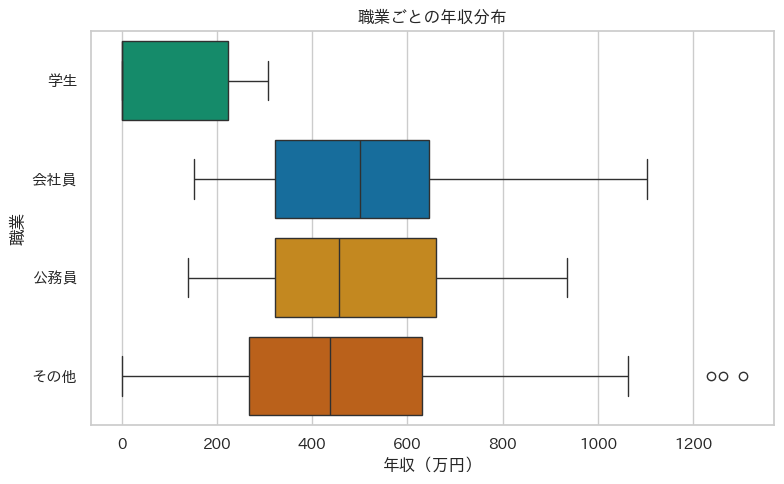

In [ ]:
ax = sns.boxplot(
    data=df,
    y="職業",
    x="年収",
    order=occupation_order,
    hue="職業",
    palette="colorblind",
    legend=False,
)
ax.set(
    title="職業ごとの年収分布",
    xlabel="年収（万円）",
    ylabel="職業",
)
plt.tight_layout()
plt.show()

#数値変数間の関係

##散布図

散布図は、2つの数値変数の組を点として表す。傾向、非線形性、群の違い、外れ値候補を確認できる。

点が重なる場合は、透明度`alpha`を下げる、点を小さくする、サンプリングするなどの工夫が必要である。

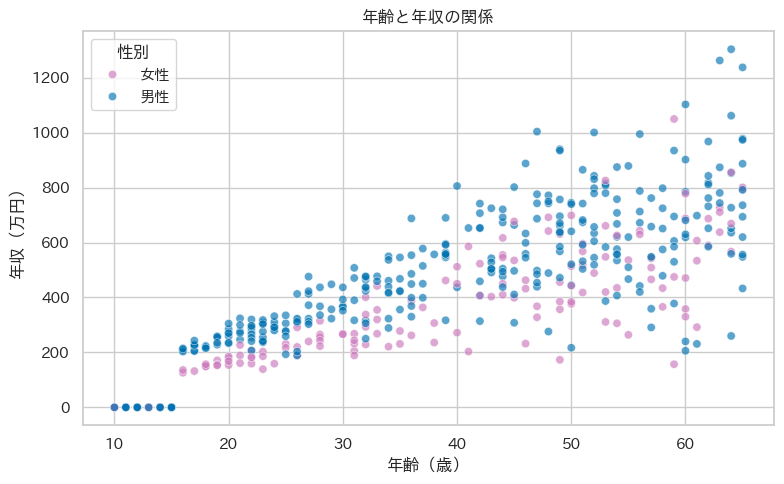

In [ ]:
ax = sns.scatterplot(
    data=df,
    x="年齢",
    y="年収",
    hue="性別",
    hue_order=gender_order,
    palette=gender_palette,
    alpha=0.65,
)
ax.set(
    title="年齢と年収の関係",
    xlabel="年齢（歳）",
    ylabel="年収（万円）",
)
ax.legend(title="性別")
plt.tight_layout()
plt.show()

##回帰線を加える

`regplot`は散布図に回帰直線と信頼帯を加える。
直線は関係を要約するものであり、
因果関係を示すものではないことに注意が必要である。
非線形な関係や群ごとの違いがある場合、一本の直線だけでは不十分である。

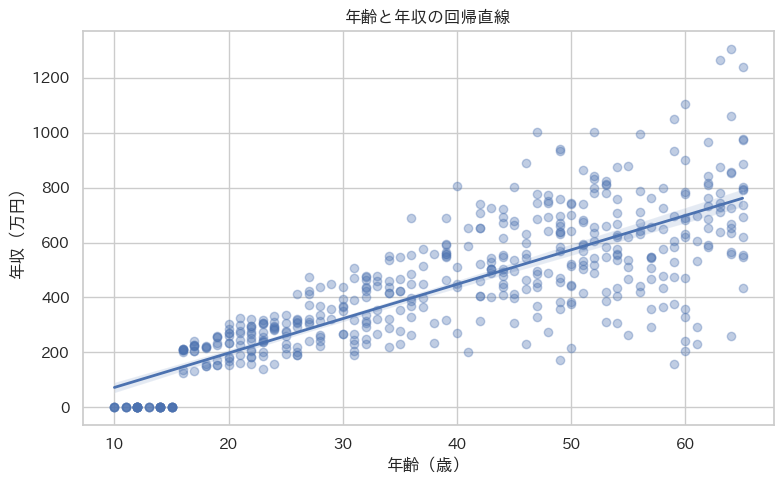

In [ ]:
ax = sns.regplot(
    data=df,
    x="年齢",
    y="年収",
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 2},
)
ax.set(
    title="年齢と年収の回帰直線",
    xlabel="年齢（歳）",
    ylabel="年収（万円）",
)
plt.tight_layout()
plt.show()

##相関係数

Pearsonの相関係数は、2つの数値変数の**線形な関係**を-1から1で表す。

- 1に近いほど強い正の線形関係である。
- -1に近いほど強い負の線形関係である。
- 0に近くても、非線形な関係が存在する場合がある。
- 外れ値の影響を受けやすい。
- 相関があっても因果関係があるとは限らない。

順序尺度では、Spearmanの順位相関を確認する必要がある。
```
method="spearman"
```
とする。


In [ ]:
pearson_corr = df[["年齢", "年収"]].corr(method="pearson").iloc[0, 1]
#spearman_corr = df[["年齢", "年収"]].corr(method="spearman").iloc[0, 1]

print(f"Pearson相関係数: {pearson_corr:.3f}")
#print(f"Spearman順位相関係数: {spearman_corr:.3f}")

Pearson相関係数: 0.809


##相関行列とヒートマップ

相関行列は多数の数値変数の関係を俯瞰するために用いる。相関の大小だけで結論を出さず、散布図と併用する必要がある。

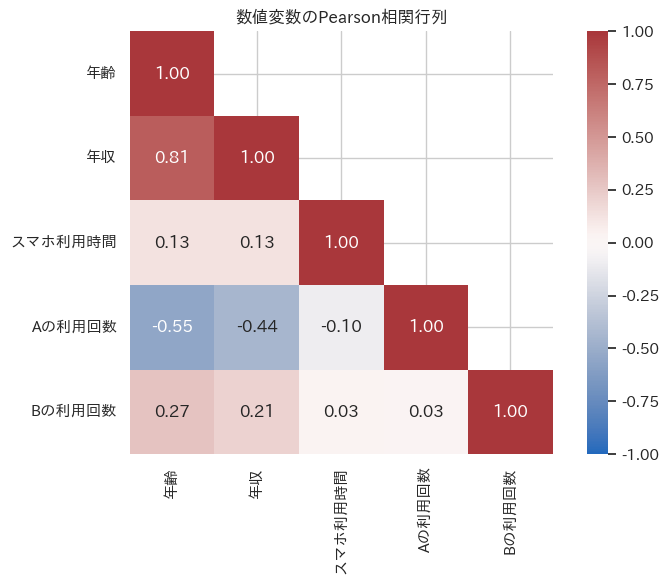

In [ ]:
corr_columns = [
    "年齢",
    "年収",
    "スマホ利用時間",
    "Aの利用回数",
    "Bの利用回数",
]
corr_matrix = df[corr_columns].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
)
ax.set_title("数値変数のPearson相関行列")
plt.tight_layout()
plt.show()

##同時分布図

`jointplot`は、散布図と各軸の分布を同時に示す。2変数の関係と周辺分布を一つの図で確認できる。

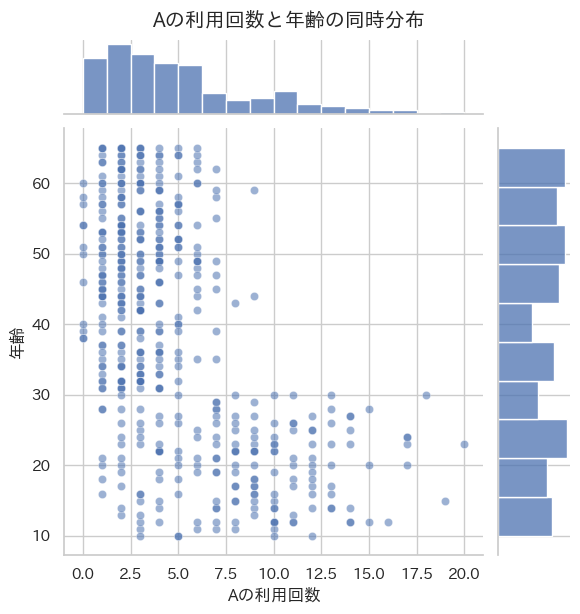

In [ ]:
g = sns.jointplot(
    data=df,
    x="Aの利用回数",
    y="年齢",
    height=6,
    alpha=0.55,
)
g.fig.suptitle("Aの利用回数と年齢の同時分布", y=1.02)
plt.show()

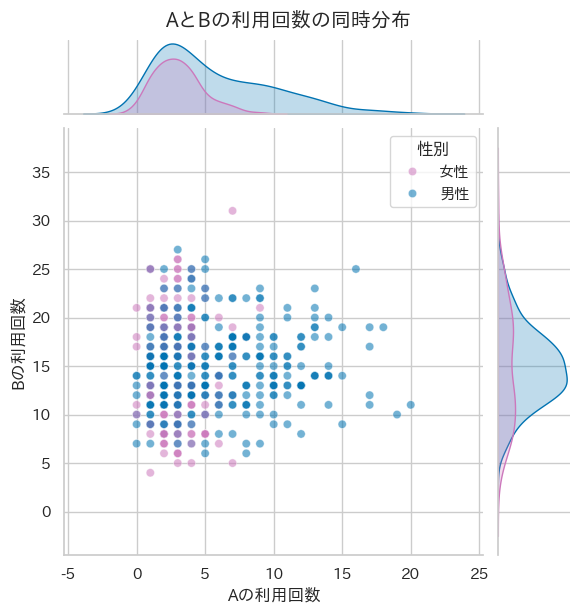

In [ ]:
g = sns.jointplot(
    data=df,
    x="Aの利用回数",
    y="Bの利用回数",
    hue="性別",
    hue_order=gender_order,
    palette=gender_palette,
    height=6,
    alpha=0.55,
)
g.fig.suptitle("AとBの利用回数の同時分布", y=1.02)
plt.show()

##散布図行列

`pairplot`は、複数の数値変数について、対角に単変量分布、非対角に散布図を表示する。変数数が多いと図が巨大になるため、目的に関係する列へ絞る必要がある。

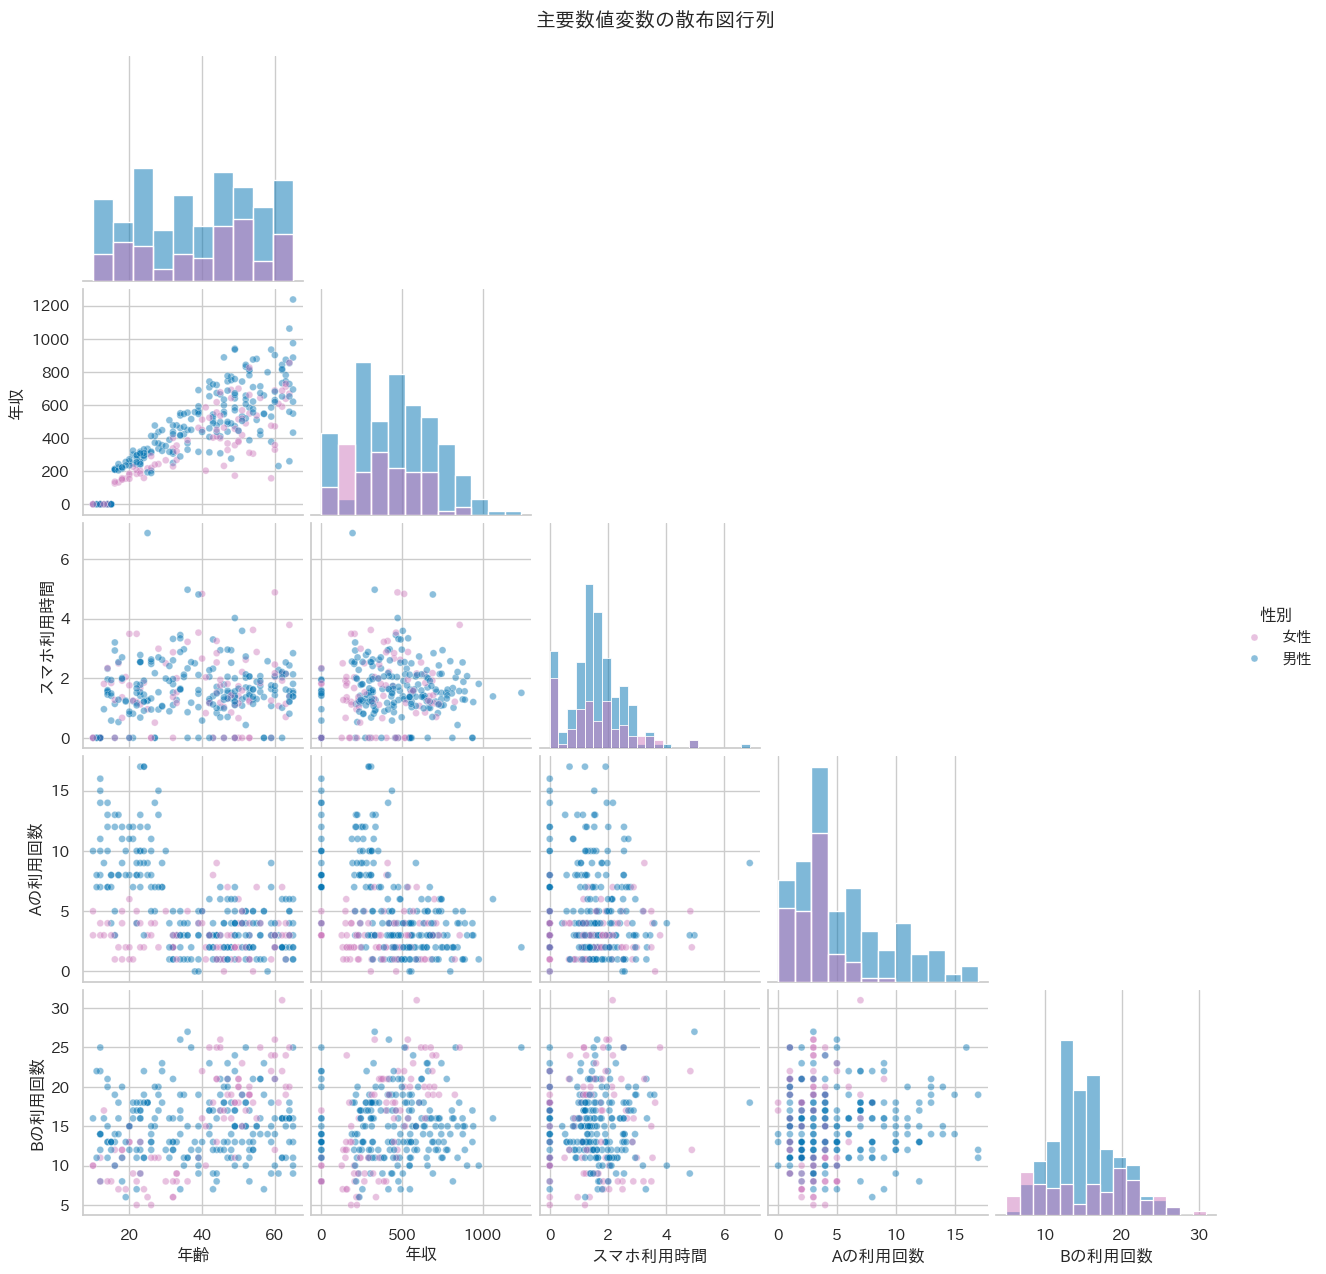

In [ ]:
pair_columns = [
    "性別",
    "年齢",
    "年収",
    "スマホ利用時間",
    "Aの利用回数",
    "Bの利用回数",
]
pair_df = df[pair_columns].sample(
    n=min(300, len(df)),
    random_state=RANDOM_SEED,
)

g = sns.pairplot(
    pair_df,
    hue="性別",
    hue_order=gender_order,
    palette=gender_palette,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.45, "s": 25},
)
g.fig.suptitle("主要数値変数の散布図行列", y=1.02)
plt.show()

##点の重なり（overplotting）への対応

観測数が多い場合や、利用回数のように同じ値を取りやすい変数では、散布図の点が重なり、実際の密度を読み違えることがある。

代表的な対処法は次のとおりである。

- 点を小さくする。
- `alpha`で透明度を下げる。
- jitterを加える。
- 2次元ヒストグラムを用いる。
- データが非常に多い場合は、目的を明示した上でサンプリングする。

次の図では、AとBの利用回数を2次元ヒストグラムで表示する。散布図では重なって見えにくい頻度の高い組合せを確認しやすい。


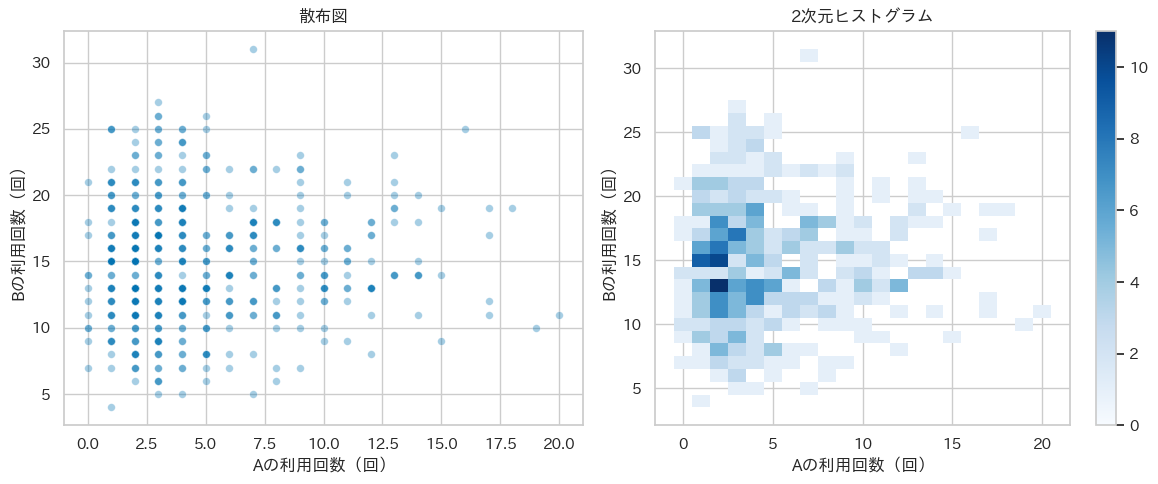

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df,
    x="Aの利用回数",
    y="Bの利用回数",
    alpha=0.35,
    s=30,
    color=BASE_COLOR,
    ax=axes[0],
)
axes[0].set(
    title="散布図",
    xlabel="Aの利用回数（回）",
    ylabel="Bの利用回数（回）",
)

sns.histplot(
    data=df,
    x="Aの利用回数",
    y="Bの利用回数",
    discrete=(True, True),
    cmap="Blues",
    cbar=True,
    ax=axes[1],
)
axes[1].set(
    title="2次元ヒストグラム",
    xlabel="Aの利用回数（回）",
    ylabel="Bの利用回数（回）",
)

plt.tight_layout()
plt.show()


##直線だけでなく非線形な関係も確認する

相関係数や直線回帰は線形な関係を要約するため、曲線的な関係を見落とす可能性がある。探索段階では散布図を先に確認し、必要に応じて平滑線を補助的に用いる。
```
lowess=True
```
とする。

平滑線の形はデータや平滑化の設定に依存するため、「真の関係」を示すものではない。あくまで関係の形を探索するための補助である。


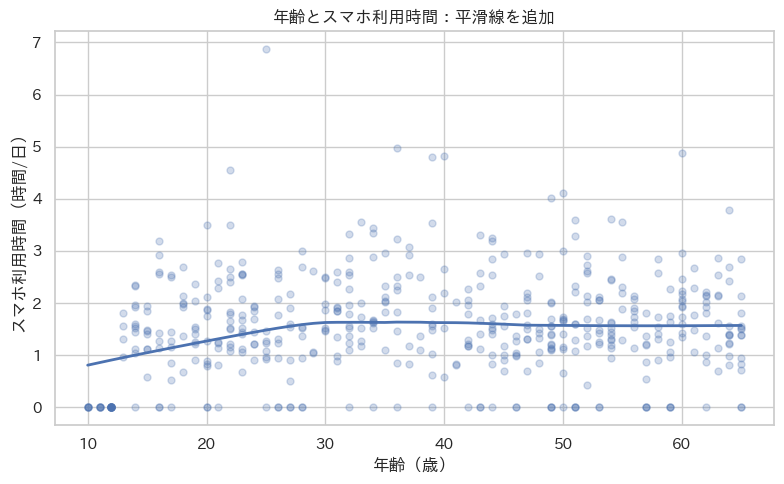

In [ ]:
ax = sns.regplot(
    data=df,
    x="年齢",
    y="スマホ利用時間",
    lowess=True,
    scatter_kws={"alpha": 0.25, "s": 25},
    line_kws={"linewidth": 2},
)
ax.set(
    title="年齢とスマホ利用時間：平滑線を追加",
    xlabel="年齢（歳）",
    ylabel="スマホ利用時間（時間/日）",
)
plt.tight_layout()
plt.show()


#カテゴリ変数間の関係

2つのカテゴリ変数の関係は、クロス集計で確認する。

In [ ]:
occupation_gender_count = pd.crosstab(df["職業"], df["性別"]).reindex(
    occupation_order
)
occupation_gender_ratio = pd.crosstab(
    df["職業"],
    df["性別"],
    normalize="index",
).reindex(occupation_order)

display(occupation_gender_count)
display(occupation_gender_ratio)

性別,女性,男性
職業,,
学生,13,56
会社員,46,90
公務員,35,96
その他,51,100


性別,女性,男性
職業,,
学生,0.19,0.81
会社員,0.34,0.66
公務員,0.27,0.73
その他,0.34,0.66


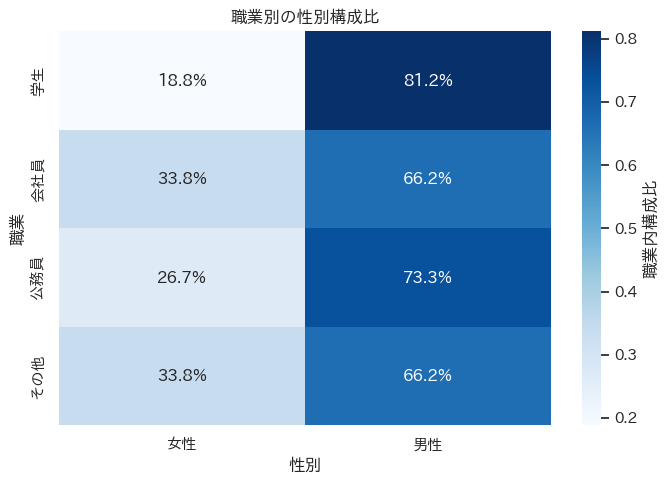

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.heatmap(
    occupation_gender_ratio,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    cbar_kws={"label": "職業内構成比"},
)
ax.set(
    title="職業別の性別構成比",
    xlabel="性別",
    ylabel="職業",
)
plt.tight_layout()
plt.show()

#複数図

`catplot`は、行または列にカテゴリを割り当てて複数図を作成できる。

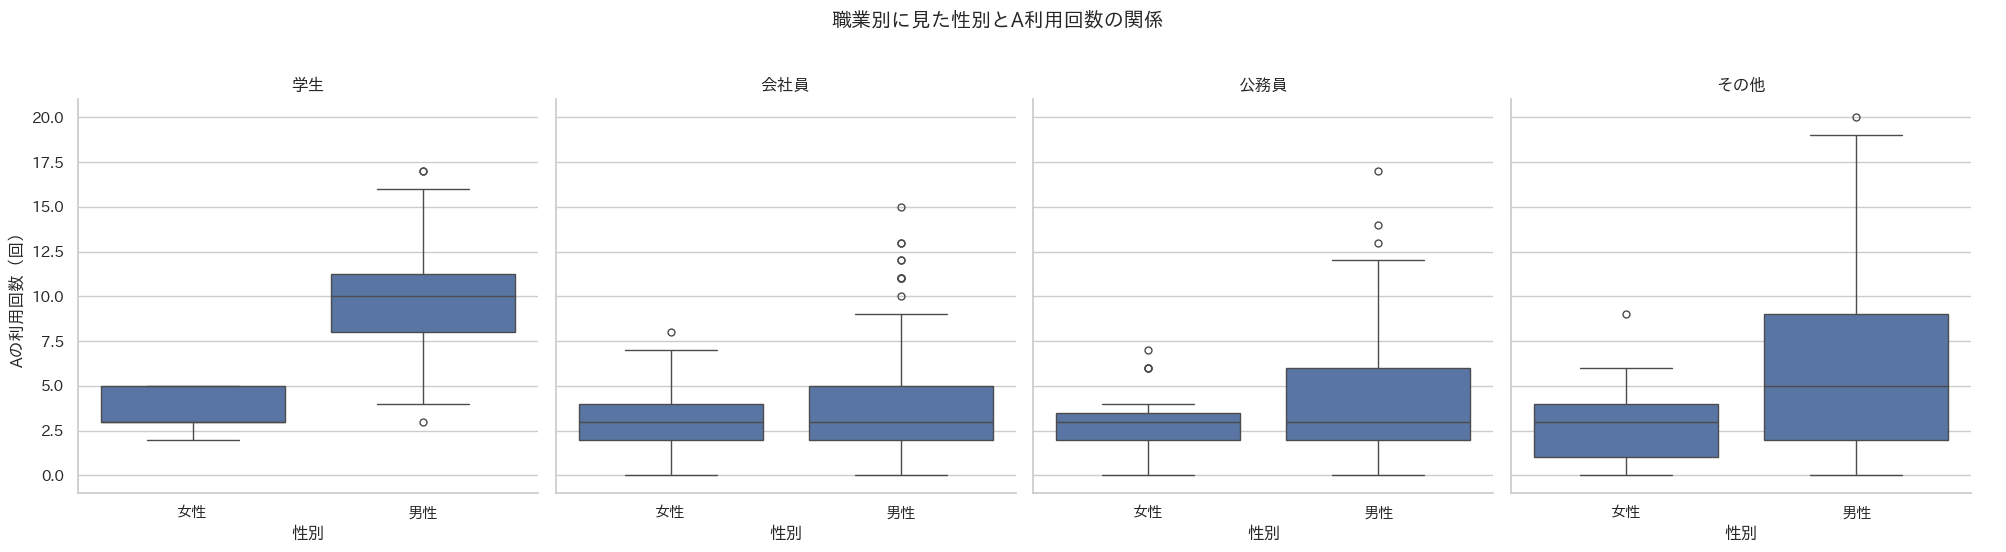

In [ ]:
g = sns.catplot(
    data=df,
    x="性別",
    y="Aの利用回数",
    col="職業",
    col_order=occupation_order,
    kind="box",
    order=gender_order
)
g.set_axis_labels("性別", "Aの利用回数（回）")
g.set_titles("{col_name}")
g.fig.suptitle("職業別に見た性別とA利用回数の関係", y=1.1)
plt.show()

kindに指定できる値の例:

- `strip`: (既定値) 一方の変数がカテゴリである散布図
- `box`: 箱ひげ図
- `point`: 点のプロット。点推定値と信頼区間が表示

- `bar`: 棒グラフ

#スタイル設定
Seabornのスタイル設定は、グラフの見た目を統一し、読みやすさを向上させるための機能である。
使う主な関数として`sns.set_theme()`と`sns.axes_style()`がある。

- `sns.set_theme(style='...')`: グリッドや背景色など、すべてのグラフに適用されるテーマを設定する。
例えば、`'whitegrid'`は白い背景にグリッド線を表示する。
- `sns.axes_style('...')`: `with`ステートメントと組み合わせて、一時的に特定のグラフにスタイルを適用する際に使用する。
- `sns.despine()`: グラフの上部と右側の境界線（スパイン）を削除し、グラフの見た目をすっきりとさせる。
- `plt.rcParams`: Matplotlibのパラメータ設定で、ここではフォントを設定する。

--- グラフ全体にwhitegridスタイルを適用 (sns.set_theme) ---


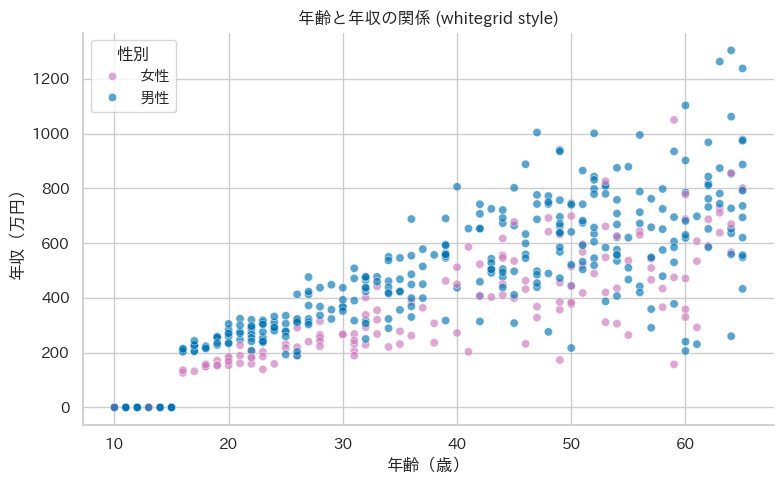


--- 一時的にdarkgridスタイルを適用 (sns.axes_style) ---


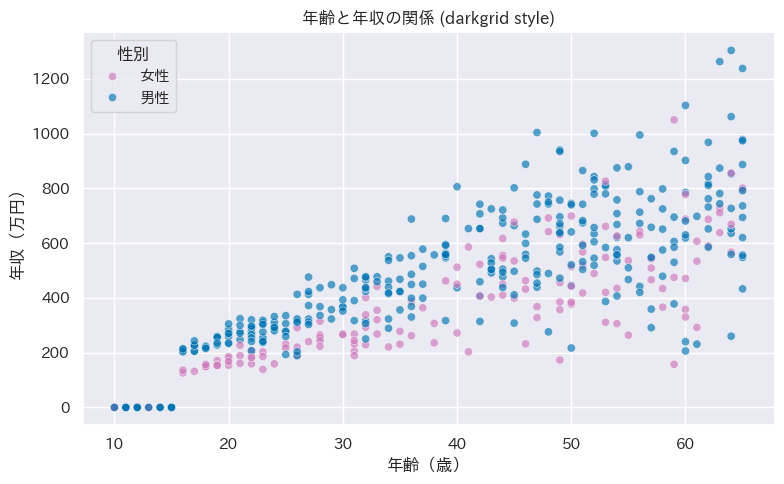


--- スタイル適用後 (元のwhitegridスタイルに戻る) ---


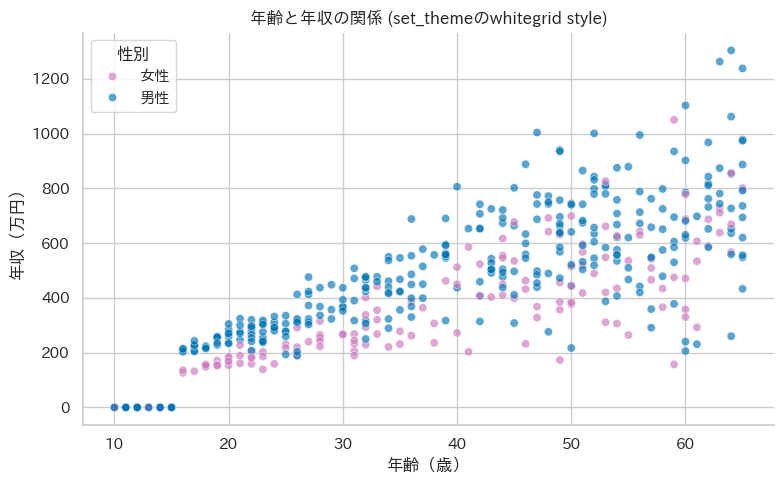

In [ ]:
print('--- グラフ全体にwhitegridスタイルを適用 (sns.set_theme) ---')
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'IPAexGothic'
ax = sns.scatterplot(
        data=df,
        x='年齢',
        y='年収',
        hue='性別',
        hue_order=gender_order,
        palette=gender_palette,
        alpha=0.65,
    )
sns.despine() # スパインを削除
ax.set(
        title='年齢と年収の関係 (whitegrid style)',
        xlabel='年齢（歳）',
        ylabel='年収（万円）',
    )
ax.legend(title='性別')
plt.tight_layout()
plt.show()

print('\n--- 一時的にdarkgridスタイルを適用 (sns.axes_style) ---')
# 一時的にdarkgridスタイルを適用
with sns.axes_style('darkgrid'):
    plt.rcParams['font.family'] = 'IPAexGothic'
    ax = sns.scatterplot(
        data=df,
        x='年齢',
        y='年収',
        hue='性別',
        hue_order=gender_order,
        palette=gender_palette,
        alpha=0.65,
    )
    sns.despine() # スパインを削除
    ax.set(
        title='年齢と年収の関係 (darkgrid style)',
        xlabel='年齢（歳）',
        ylabel='年収（万円）',
    )
    ax.legend(title='性別')
    plt.tight_layout()
    plt.show()

print('\n--- スタイル適用後 (元のwhitegridスタイルに戻る) ---')
ax = sns.scatterplot(
        data=df,
        x='年齢',
        y='年収',
        hue='性別',
        hue_order=gender_order,
        palette=gender_palette,
        alpha=0.65,
    )
sns.despine() # スパインを削除
ax.set(
        title='年齢と年収の関係 (set_themeのwhitegrid style)',
        xlabel='年齢（歳）',
        ylabel='年収（万円）',
    )
ax.legend(title='性別')
plt.tight_layout()
plt.show()

#グラフの保存

`savefig`を用いてPNG、PDF、SVGなどへ保存できる。レポートやスライドでは、用途に応じて解像度と形式を選ぶ。

- PNGは画面表示やスライドに適する。
- PDFやSVGは拡大しても劣化しにくく、印刷物に適する。
- `bbox_inches="tight"`は余白を自動調整する。

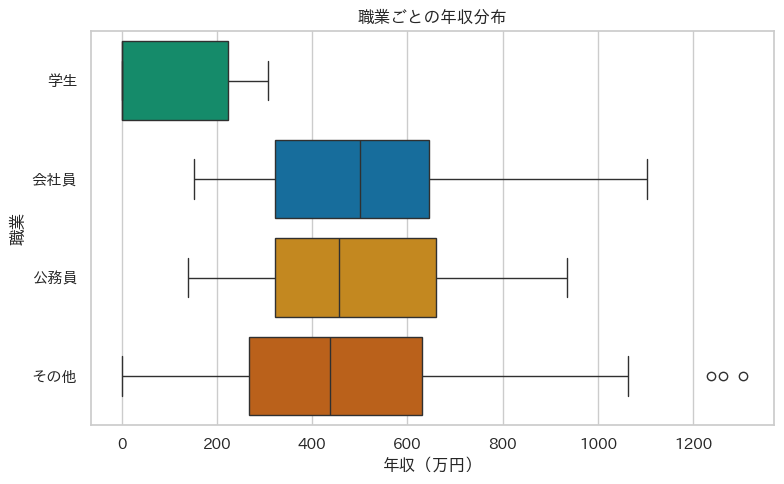

保存先: /content/figures/occupation_income_boxplot.png


In [ ]:
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    y="職業",
    x="年収",
    order=occupation_order,
    hue="職業",
    palette="colorblind",
    legend=False,
    ax=ax,
)
ax.set(
    title="職業ごとの年収分布",
    xlabel="年収（万円）",
    ylabel="職業",
)
fig.tight_layout()

figure_path = output_dir / "occupation_income_boxplot.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"保存先: {figure_path.resolve()}")

#まとめ

データ理解のための可視化は、次の順序で行うと整理しやすい。

| 段階 | 主な問い | 代表的な可視化 | 次の確認事項 |
|---|---|---|---|
| 1. 品質 | 欠損・重複・異常値はあるか | 欠損率棒グラフ、欠損パターン図、箱ひげ図 | 原因、業務ルール、処理方針 |
| 2. 単変量 | 各変数はどのように分布するか | countplot、histplot、ECDF、boxplot | 偏り、歪み、希少カテゴリ |
| 3. 二変量 | 2変数には関係があるか | boxplot、scatterplot、heatmap | 群差、非線形性、交絡候補 |
| 4. 多変量 | 関係は第三の変数で変わるか | hue、facet、pairplot | セグメント別の違い |
| 5. 感度 | 見え方は設定で変わらないか | bins変更、尺度変更、別グラフ | 結論の頑健性 |
| 6. 仮説化 | 次に何を調べるべきか | 必要な図を再作成 | 追加データ、統計分析、業務確認 |

### EDAで重要な考え方

**1つの図から結論を確定しない**ことが重要である。例えば、平均差が見えた場合でも、箱ひげ図や個票を確認すると、一部の外れ値や群のサンプル数の違いによって見えていた差であることが分かる場合がある。

可視化の役割は、次の3つである。

1. **異常を発見する**：欠損、外れ値候補、不自然な集中などを見つける。
2. **構造を発見する**：分布、群間差、変数間関係、非線形性を見つける。
3. **次の問いを作る**：追加確認、データ収集、モデル化、統計的検証につなげる。


# 参考資料

- seaborn公式ドキュメント: <https://seaborn.pydata.org/>
